Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset shape: (768, 9)

Training samples: 614
Validation/Test samples: 154


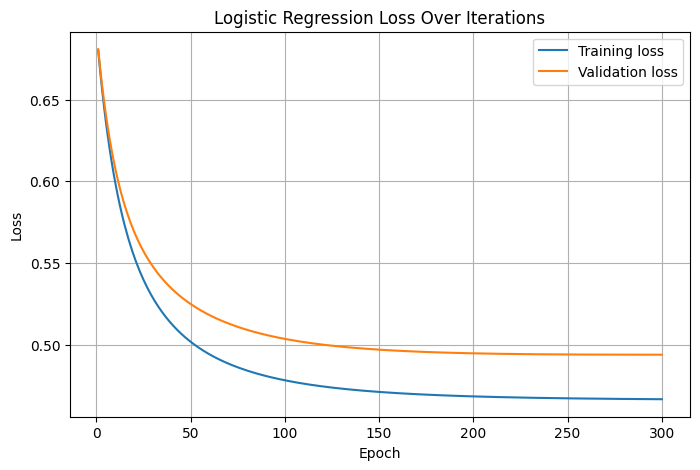

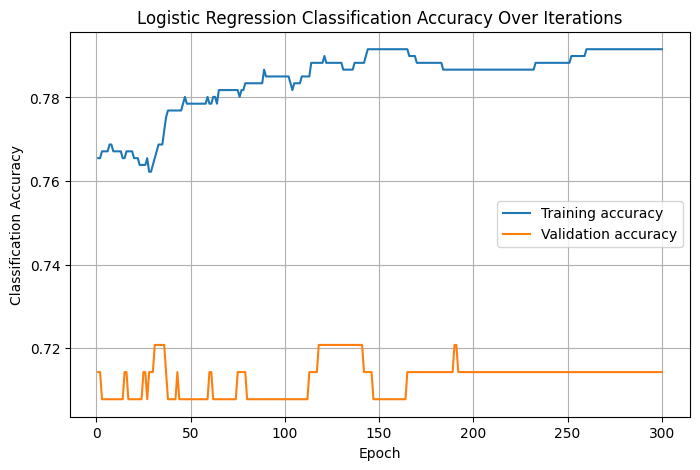


Final Evaluation(Test) Results
--------------------------------
Accuracy  : 0.7143
Precision : 0.6136
Recall    : 0.5000
F1 Score  : 0.5510

Percentage Form
----------------
Accuracy  : 71.43%
Precision : 61.36%
Recall    : 50.00%
F1 Score  : 55.10%

Confusion Matrix:
[[83 17]
 [27 27]]


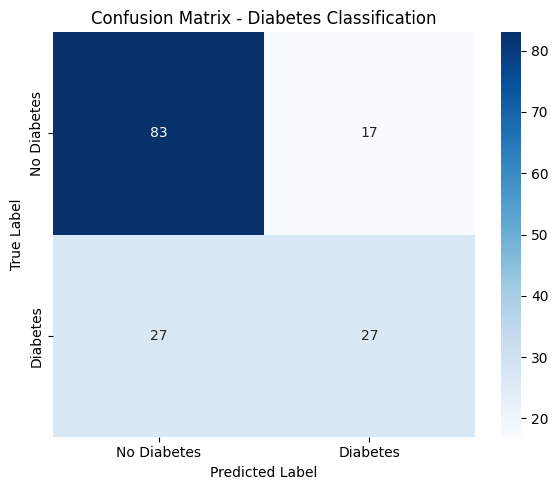

In [5]:
# ============================================================
# HOMEWORK 3 - PROBLEM 1
# Logistic Regression Binary Classifier for Diabetes
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# ============================================================
# 1. Mount Google Drive
# ============================================================

drive.mount('/content/drive')


# ============================================================
# 2. Load Dataset
# ============================================================

file_path = '/content/drive/MyDrive/diabetes.csv'
dataset = pd.read_csv(file_path)

print("First 5 rows:")
print(dataset.head())

print("\nDataset shape:", dataset.shape)


# ============================================================
# 3. Separate Features and Target
# ============================================================

# First 8 columns = input features
X = dataset.iloc[:, 0:8].values

# Last column = target
# 0 = No Diabetes
# 1 = Positive Diabetes
y = dataset.iloc[:, 8].values


# ============================================================
# 4. Split into 80% Training and 20% Evaluation(Test)
# ============================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining samples:", X_train.shape[0])
print("Validation/Test samples:", X_val.shape[0])


# ============================================================
# 5. Standardize Features
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)


# ============================================================
# 6. Logistic Regression Helper Functions
# ============================================================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy(y_true, y_prob):
    epsilon = 1e-15
    y_prob = np.clip(y_prob, epsilon, 1 - epsilon)

    loss = -np.mean(
        y_true * np.log(y_prob) +
        (1 - y_true) * np.log(1 - y_prob)
    )
    return loss


# ============================================================
# 7. Initialize Parameters
# ============================================================

n_features = X_train.shape[1]

weights = np.zeros(n_features)
bias = 0.0

learning_rate = 0.1
num_iterations = 300


# ============================================================
# 8. Store Results Over Iterations
# ============================================================

train_loss_history = []
val_loss_history = []

train_acc_history = []
val_acc_history = []


# ============================================================
# 9. Train Logistic Regression Using Gradient Descent
# ============================================================

m = X_train.shape[0]

for i in range(num_iterations):

    # ---------------------------
    # Forward pass on training set
    # ---------------------------
    z_train = np.dot(X_train, weights) + bias
    y_train_prob = sigmoid(z_train)

    # ---------------------------
    # Compute gradients
    # ---------------------------
    error = y_train_prob - y_train

    dw = (1 / m) * np.dot(X_train.T, error)
    db = (1 / m) * np.sum(error)

    # ---------------------------
    # Update parameters
    # ---------------------------
    weights = weights - learning_rate * dw
    bias = bias - learning_rate * db

    # ---------------------------
    # Training loss and accuracy
    # ---------------------------
    z_train = np.dot(X_train, weights) + bias
    y_train_prob = sigmoid(z_train)
    y_train_pred = (y_train_prob >= 0.5).astype(int)

    train_loss = binary_cross_entropy(y_train, y_train_prob)
    train_acc = accuracy_score(y_train, y_train_pred)

    # ---------------------------
    # Validation loss and accuracy
    # ---------------------------
    z_val = np.dot(X_val, weights) + bias
    y_val_prob = sigmoid(z_val)
    y_val_pred = (y_val_prob >= 0.5).astype(int)

    val_loss = binary_cross_entropy(y_val, y_val_prob)
    val_acc = accuracy_score(y_val, y_val_pred)

    # ---------------------------
    # Save results
    # ---------------------------
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)


# ============================================================
# 10. Plot Loss Over Iterations
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(range(1, num_iterations + 1), train_loss_history, label='Training loss')
plt.plot(range(1, num_iterations + 1), val_loss_history, label='Validation loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Logistic Regression Loss Over Iterations')
plt.legend()
plt.grid(True)

# Optional: to make it look more like professor's sample
# plt.yscale('log')

plt.show()


# ============================================================
# 11. Plot Classification Accuracy Over Iterations
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(range(1, num_iterations + 1), train_acc_history, label='Training accuracy')
plt.plot(range(1, num_iterations + 1), val_acc_history, label='Validation accuracy')

plt.xlabel('Epoch')
plt.ylabel('Classification Accuracy')
plt.title('Logistic Regression Classification Accuracy Over Iterations')
plt.legend()
plt.grid(True)

plt.show()


# ============================================================
# 12. Final Prediction on Validation/Test Set
# ============================================================

z_val = np.dot(X_val, weights) + bias
y_val_prob = sigmoid(z_val)
y_pred = (y_val_prob >= 0.5).astype(int)


# ============================================================
# 13. Report Final Results
# ============================================================

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("\nFinal Evaluation(Test) Results")
print("--------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

print("\nPercentage Form")
print("----------------")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision * 100:.2f}%")
print(f"Recall    : {recall * 100:.2f}%")
print(f"F1 Score  : {f1 * 100:.2f}%")


# ============================================================
# 14. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_val, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ============================================================
# 15. Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='g',
    cmap='Blues',
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

plt.title('Confusion Matrix - Diabetes Classification')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()